
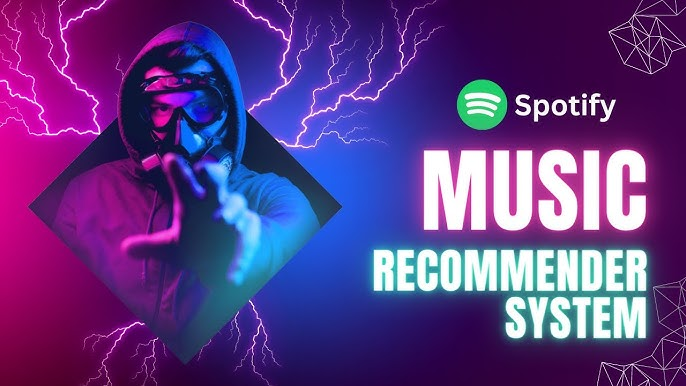

#**Project Summary:** Spotify Music Recommendation System Using Cosine Similarity

#**Overview**
This project develops a content-based music recommendation system using text vectorization and cosine similarity to recommend songs with similar characteristics. By transforming music-related metadata and textual features into vectorized representations, the system intelligently identifies tracks that closely match a user’s selected song or listening preference.
The model successfully generated accurate and relevant music recommendations based on similarity scoring.


#**Aim of the Project**
To build a personalized music recommendation engine capable of suggesting similar songs automatically.
To apply vectorization and cosine similarity techniques for content-based recommendation.
To demonstrate practical machine learning applications in music streaming and user personalization systems.

##**Import Libries**

In [99]:
import pandas as pd
import numpy as np
from google.colab import drive


##**Mount Drive**

In [82]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Load Data**

In [83]:
songs_data = pd.read_csv("/content/drive/My Drive/Datasets/spotify_data clean.csv")

In [84]:
songs_data.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


##**Data Exploration**

In [85]:
songs_data['track_name'][0]

'Trippy Mane (ft. Project Pat)'

In [86]:
songs_data.columns

Index(['track_id', 'track_name', 'track_number', 'track_popularity',
       'explicit', 'artist_name', 'artist_popularity', 'artist_followers',
       'artist_genres', 'album_id', 'album_name', 'album_release_date',
       'album_total_tracks', 'album_type', 'track_duration_min'],
      dtype='object')

In [87]:
songs = songs_data[["track_name","artist_name","artist_genres"]]

print("Dupliocated_data: ", songs.duplicated().sum())

print("None values: ",songs.isna().sum())



Dupliocated_data:  659
None values:  track_name          0
artist_name         3
artist_genres    3361
dtype: int64


In [88]:
songs = songs.dropna().drop_duplicates().reset_index(drop=True)
songs

,track_name,artist_name,artist_genres
0,Trippy Mane (ft. Project Pat),Diplo,moombahton
1,OMG!,Yelawolf,"country hip hop, southern hip hop"
2,Still Get Like That (ft. Project Pat & Starrah),Diplo,moombahton
3,ride me like a harley,Rumelis,dark r&b
4,BLEED,Minzie,dark r&b
...,...,...,...
4811,Big Iron,Marty Robbins,"classic country, outlaw country"
4812,El Paso,Marty Robbins,"classic country, outlaw country"
4813,Over the Rainbow,The Mystics,doo-wop
4814,I'm A Man,Bo Diddley,"blues, classic blues, rock and roll, rockabilly"


In [89]:
print("Dupliocated_data: ", songs.duplicated().sum())

print("None values: ",songs.isna().sum())


Dupliocated_data:  0
None values:  track_name       0
artist_name      0
artist_genres    0
dtype: int64


In [97]:
songs.shape

(4816, 3)

##**Importing TfidfVectorizer to vectorize our text**

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf  = TfidfVectorizer( analyzer="word", stop_words="english")
matrix = tfidf.fit_transform(songs["artist_genres"])

In [92]:
matrix.shape

(4816, 338)

##**Importing cosine_similarity to find the nearest word in meaning**

In [93]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(matrix)

array([[1.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.18956866],
       [1.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.04993697],
       [0.        , 0.18956866, 0.        , ..., 0.        , 0.04993697,
        1.        ]])

In [94]:
def get_recommendations(track_name):
  idx = songs[songs["track_name"].str.lower() == track_name.lower()].index[0]
  sim_scores = sorted(list(enumerate(cosine_similarity(matrix[idx], matrix).flatten())), reverse=True,  key= lambda item: item[1])
  for i in sim_scores[1:11]:
    print(songs.iloc[i[0]].track_name)

In [95]:
print(get_recommendations("bleed"))

BLEED
come closer
baby can you sin for me
i don't need ur love
Psycho
Rush From You
CRAVE
Sacrifice
Don't u cry
need u
None


In [98]:
import joblib
import os

output_dir = "/content/drive/My Drive/Models/Advanced Project/Recommendation System/Songs Recommendation/"
os.makedirs(output_dir, exist_ok=True)

joblib.dump(matrix, os.path.join(output_dir, "matrix.joblib"))
joblib.dump(tfidf, os.path.join(output_dir, "tfidf.joblib"))
joblib.dump(songs, os.path.join(output_dir, "songs.joblib"))

['/content/drive/My Drive/Models/Advanced Project/Recommendation System/Songs Recommendation/songs.joblib']

#**Conclusion / Deployment Summary**

##**When deployed, this system can:**

Recommend songs with similar styles, moods, or characteristics in real time.
Improve user engagement and listening experience on music platforms.
Serve as a scalable recommendation module for streaming services, playlists, or AI-driven entertainment applications.

The project highlights strong skills in recommendation systems, similarity modeling, and NLP-based feature engineering.